# 01 — 합성 DGP 해부: 백스테이지가 참값을 아는 이유

> **지위 배너 — 재현/탐색 층.** 이 노트북이 새로 계산하는 수치는 전부 **LEDGER 미등재
> (정본 아님)** 이다. 정본 수치는 [`docs/LEDGER.md`](../docs/LEDGER.md) 뿐이며, 기존 결과를
> 인용할 때는 행 id 를 병기한다. 규약: [`notebooks/README.md`](README.md).
> **무대 라벨 — 백스테이지.** 이 권이 여는 oracle 층은 실무에 존재하지 않는다 — 그래서 본편
> 신호를 채점할 무대가 필요하다(GLOSSARY §8).

이 레포의 백스테이지(합성 축 01–10·확장 14·17–19 의 reveal 층)가 성립하는 이유는 하나다 —
**DGP 가 참값을 알기 때문**이다. M8 이후 이 무대는 본편(GT-미상 프로토콜)의 신호를 채점하는
검증 층이다. `SyntheticBanditData` 는 두 층으로 갈라져 있다: estimator 가 보는 **로그 층**
(context·action·reward·`pscore_logged`·`pi_e_dist`)과, 채점에만 쓰이는 **oracle 층**(`q_true`·
`pscore_true`·`v_true`) — 이 두 층 구분이 M8 의 본편(frontstage)/백스테이지(backstage) 언어의
원형이다(GLOSSARY §8). 이 권은 그 장치를 연다 — `DGPConfig` 의 노브 하나하나가 어떤 기하를
만들고, 그 기하가 어떤 실험 축(02·03·04·09)의 데이터적 기원인지를 눈으로 확인한다.

정본 owner 는 [`src/ope/dgp.py`](../src/ope/dgp.py)(구현·설계 결정 주석)와 `PLAN.md` §2
(노브↔축 매핑)다. 여기서 쓰는 config 는 [`configs/dgp/default.yaml`](../configs/dgp/default.yaml)
의 설계 기본값(n=10,000 · K=10 · d=5 · β_log=1 · β_eval=3)이다.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():  # notebooks/ 또는 repo 루트 어디서 실행해도 동작
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "experiments"))

from _style import CONTEXT_GRAY, ESTIMATOR_COLORS, ORACLE_COLOR, apply_style  # noqa: E402

# _style 은 스크립트용으로 Agg 백엔드를 강제한다 — 노트북에서는 inline 렌더로 복원
%matplotlib inline
apply_style()
import matplotlib.pyplot as plt  # noqa: E402

from ope.dgp import (  # noqa: E402
    CONF_REWARD_SCALE,
    DGPConfig,
    make_synthetic_bandit_data,
    marginal_logging_dist,
    true_policy_value,
)
from ope.policies import softmax_policy  # noqa: E402

ACCENT = ESTIMATOR_COLORS["dm"]      # 기본 계열(blue) — 팔레트는 entity 고정 규약의 prefix 재사용
ACCENT2 = ESTIMATOR_COLORS["ips"]    # 대조 계열(orange)
SWEEP_COLORS = [ESTIMATOR_COLORS[k] for k in ("dm", "ips", "snips", "dros")]  # 4값 스윕 공용

BASE = DGPConfig(
    n=10_000, n_actions=10, dim_context=5,
    beta_log=1.0, beta_eval=3.0,
    support_deficiency=0.0, reward_noise=0.5, confounding_strength=0.0,
    seed=12345, struct_seed=7,
)  # configs/dgp/default.yaml 과 동일한 설계 기본값

## A. q 와 정책 기하 — 두 정책은 같은 스코어의 온도 차이일 뿐이다

환경의 심장은 참 기대보상 `q(x,a) = sigmoid(x·θ_a + b_a)` 하나다. 로깅 정책도 평가 정책도
**같은 q 의 softmax(β·q)** 이고, 다른 것은 inverse-temperature β 뿐이다(β_log=1 vs β_eval=3).
먼저 로그 층/oracle 층의 분리를 확인하고, q 가 만드는 "정책이 벌릴 수 있는 여지"를 본다.

In [2]:
base = make_synthetic_bandit_data(BASE)
q = base.q_true  # (n, K) — oracle 층

LOGGED_FIELDS = {"context", "action", "reward", "pscore_logged", "pi_e_dist"}
print("SyntheticBanditData 필드 — estimator 가 보는 로그 층 vs 채점 전용 oracle 층")
for f in base._fields:
    v = getattr(base, f)
    shape = v.shape if hasattr(v, "shape") else "scalar"
    layer = "logged" if f in LOGGED_FIELDS else "ORACLE"
    print(f"  [{layer:6s}] {f:14s} {shape}")

# π_e 재조립 검산 — pi_e_dist 는 정확히 softmax(β_eval·q_true) 다
assert np.allclose(base.pi_e_dist, softmax_policy(base.q_true, BASE.beta_eval))
print("\n재조립 검산 OK: pi_e_dist == softmax(beta_eval * q_true)")

SyntheticBanditData 필드 — estimator 가 보는 로그 층 vs 채점 전용 oracle 층
  [logged] context        (10000, 5)
  [logged] action         (10000,)
  [logged] reward         (10000,)
  [logged] pscore_logged  (10000,)
  [ORACLE] pscore_true    (10000,)
  [logged] pi_e_dist      (10000, 10)
  [ORACLE] q_true         (10000, 10)
  [ORACLE] v_true         scalar
  [ORACLE] pi_log_dist    (10000, 10)

재조립 검산 OK: pi_e_dist == softmax(beta_eval * q_true)


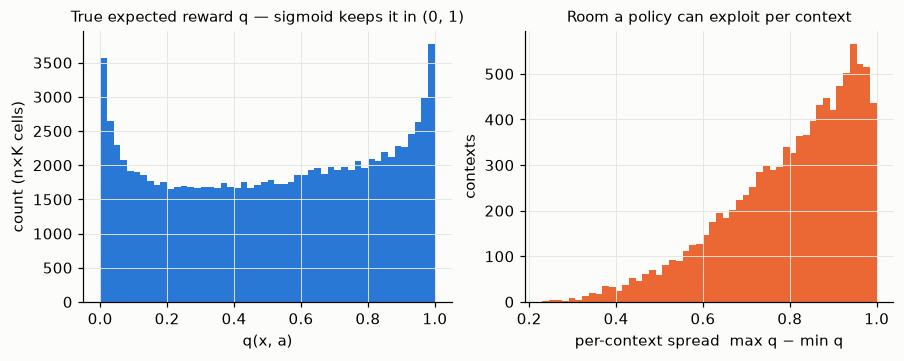

In [3]:
spread = q.max(axis=1) - q.min(axis=1)  # 컨텍스트별로 정책이 벌릴 수 있는 스코어 폭

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
axes[0].hist(q.ravel(), bins=50, color=ACCENT)
axes[0].set_xlabel("q(x, a)")
axes[0].set_ylabel("count (n$\\times$K cells)")
axes[0].set_title("True expected reward q — sigmoid keeps it in (0, 1)", fontsize=10)
axes[1].hist(spread, bins=50, color=ACCENT2)
axes[1].set_xlabel("per-context spread  max q $-$ min q")
axes[1].set_ylabel("contexts")
axes[1].set_title("Room a policy can exploit per context", fontsize=10)
plt.show()

q 는 sigmoid 로 (0,1) 에 갇힌다 — 따라서 softmax 의 logit `β·q` 도 유계다. 이 유계성이 뒤
섹션 B 의 weight 기하와 스트레치 축 13 의 운명(아래 참조)을 미리 결정한다. 이제 **한
컨텍스트**를 골라(스코어 폭이 가장 큰 컨텍스트 — β 효과가 잘 보인다) β 를 올리면 행동
분포가 얼마나 뾰족해지는지 본다. β→0 이면 uniform, β→∞ 면 준결정적(overlap 붕괴)이라는
`softmax_policy` docstring 의 양 극단 사이를 β∈{0.5, 1, 3, 6} 으로 걷는다.

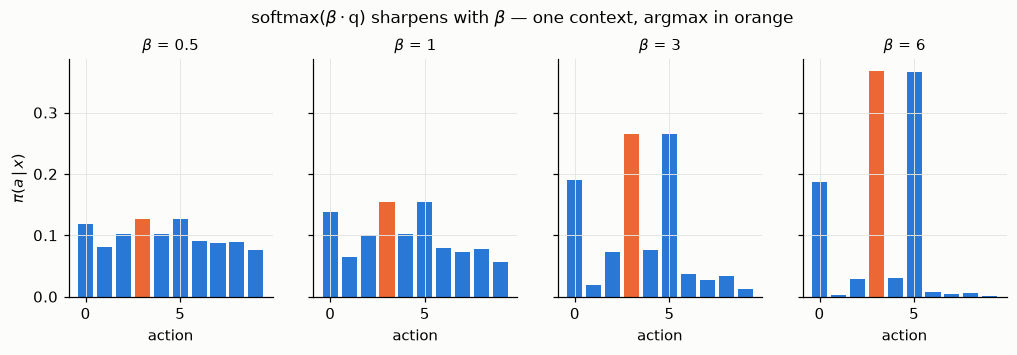

In [4]:
BETAS_SHOW = (0.5, 1.0, 3.0, 6.0)
i_ctx = int(np.argmax(spread))
qi = q[i_ctx:i_ctx + 1]

fig, axes = plt.subplots(1, 4, figsize=(11, 2.8), sharey=True)
for ax, beta in zip(axes, BETAS_SHOW):
    pi = softmax_policy(qi, beta)[0]
    colors = [ACCENT2 if a == int(pi.argmax()) else ACCENT for a in range(len(pi))]
    ax.bar(np.arange(len(pi)), pi, color=colors)
    ax.set_title(f"$\\beta$ = {beta:g}", fontsize=10)
    ax.set_xlabel("action")
axes[0].set_ylabel("$\\pi(a\\,|\\,x)$")
fig.suptitle("softmax($\\beta\\cdot$q) sharpens with $\\beta$ — one context, argmax in orange",
             y=1.04, fontsize=11)
plt.show()

β=0.5 는 거의 uniform, β=6 은 argmax 근처로 질량이 쏠린다. **로깅 β_log 를 올리면 이
뾰족함이 "로그가 무엇을 담는가"를 결정하고, 평가 β_eval 을 올리면 "무엇을 물어보는가"를
결정한다** — 두 온도의 괴리가 곧 importance weight 다. 다음 섹션에서 그 다이얼을 돌린다.

## B. weight 기하 = overlap 다이얼 — IPS 붕괴는 로깅 집중도가 평가와 어긋날 때 온다

w = π_e/π_0 를 로그 행동에서 평가하면 IPS 의 원료가 된다. β_eval=3 을 고정하고 **β_log 를
{0.5, 1, 4, 8} 로 스윕**하면, 같은 환경에서 로깅 온도 하나가 weight 기하 전체를 바꾸는 것을
볼 수 있다 — 축 02(로깅 β)·축 03(타깃-로깅 괴리)의 데이터적 기원이다(정본 스윕은
`experiments/02_*.py`·`03_*.py`, 코어 축 완비는 LEDGER `m2-gate`).

In [5]:
BETAS_LOG = (0.5, 1.0, 4.0, 8.0)
w_by_beta = {}
rows = []
for beta_log in BETAS_LOG:
    d = make_synthetic_bandit_data(BASE._replace(beta_log=beta_log))
    idx = np.arange(len(d.action))
    w = d.pi_e_dist[idx, d.action] / d.pscore_logged
    w_by_beta[beta_log] = w
    rows.append({
        "beta_log": beta_log,
        "pscore_min": d.pscore_logged.min(),
        "max_w": w.max(),
        "p99_w": np.quantile(w, 0.99),
        "ess_ratio": (w.sum() ** 2 / (w ** 2).sum()) / len(w),
        "share_w_gt_5": (w > 5).mean(),
    })
w_summary = pd.DataFrame(rows).set_index("beta_log")
display(w_summary.style.format({"pscore_min": "{:.2e}", "max_w": "{:.1f}", "p99_w": "{:.2f}",
                                "ess_ratio": "{:.3f}", "share_w_gt_5": "{:.4f}"}))

,pscore_min,max_w,p99_w,ess_ratio,share_w_gt_5
beta_log,,,,,
0.500000,6.98e-02,3.9,2.53,0.743,0.0000
1.000000,4.97e-02,2.8,2.06,0.827,0.0000
4.000000,4.62e-03,2.4,1.84,0.956,0.0000
8.000000,2.30e-04,62.6,6.54,0.256,0.0165


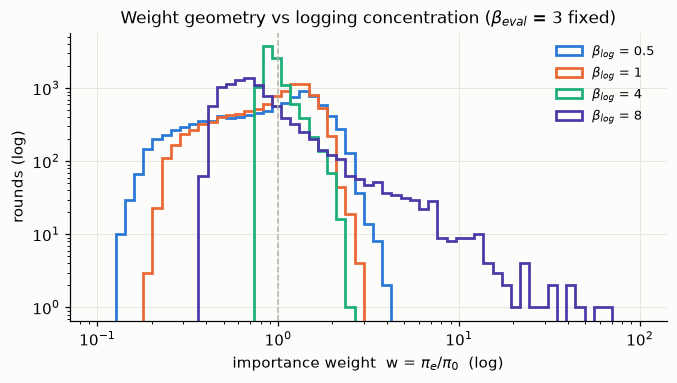

In [6]:
wmin = min(w.min() for w in w_by_beta.values())
wmax = max(w.max() for w in w_by_beta.values())
bins = np.logspace(np.floor(np.log10(wmin)), np.ceil(np.log10(wmax)), 60)

fig, ax = plt.subplots(figsize=(7, 3.4))
for (beta_log, w), color in zip(w_by_beta.items(), SWEEP_COLORS):
    ax.hist(w, bins=bins, histtype="step", lw=1.8, color=color,
            label=f"$\\beta_{{log}}$ = {beta_log:g}")
ax.axvline(1.0, color=CONTEXT_GRAY, lw=1, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")  # 꼬리 가시화 — 선형축에서는 β_log=8 의 소수 대형 w 가 보이지 않는다
ax.set_xlabel("importance weight  w = $\\pi_e$/$\\pi_0$  (log)")
ax.set_ylabel("rounds (log)")
ax.set_title("Weight geometry vs logging concentration ($\\beta_{eval}$ = 3 fixed)", fontsize=11)
ax.legend()
plt.show()

표를 그대로 읽으면 이야기는 단조가 아니다 — **ESS ratio 는 β_log 가 β_eval 에 다가갈수록
오히려 좋아지다가(로깅 집중이 평가가 원하는 곳과 *정렬*), β_log 가 그 너머로 가면 pscore
최소값이 1e-4 급으로 떨어지며 무너진다.** 즉 IPS 를 죽이는 것은 집중도 자체가 아니라
**집중과 괴리의 결합**이다: 로깅이 확신에 찼는데 그 확신이 평가 정책과 다른 곳을 볼 때,
평가가 좋아하는데 로그에 드물게 남은 행동 하나하나가 큰 w 를 짊어진다. 축 02(β_log 스윕)와
축 03(β_eval 괴리 스윕)이 이 결합을 두 방향에서 자르는 이유다. **정직 병기**: 이 DGP family
는 logit 이 β·q 로 유계라 w 도 유계다 — "액션 수 폭발만으로 IPS 붕괴" 서사가 여기서 성립하지
않는다는 것이 스트레치 축 13 probe 의 NO-GO 기록(LEDGER `m5-probe-13`)이고, 그 기하적
이유가 바로 섹션 A 의 (0,1) 유계성이다.

## C. support mask(δ) — 기록 propensity 에 구조적 0 을 심는 장치

축 04 의 노브 `support_deficiency=δ` 는 **컨텍스트별 하위-q ⌊δK⌋개 행동**의 로깅 지지를
구조적으로 제거한다(per-row 랜덤 mask 가 아님 — `dgp.py` 설계 결정 주석). mask 는 배포
설정이므로 기록 propensity 분포에도 0 이 그대로 새겨지고, π_e 는 불변이다 — 즉 **π_e 가
원하는 행동이 로그에 원리적으로 등장하지 않는** 식별 불능 구조가 생긴다. δ∈{0, 0.2, 0.4}
로 그 구조를 열어 본다(K=10 이므로 ⌊δK⌋ = 0·2·4 개 — δ 스윕은 1/K 단위로 양자화).

In [7]:
from ope.dgp import _masked_softmax, _support_mask  # noqa: E402 — 해부 전용(정본 사용법 아님)

DELTAS = (0.0, 0.2, 0.4)
data_by_delta, mask_by_delta, unsup_by_delta = {}, {}, {}
rows = []
for delta in DELTAS:
    d = make_synthetic_bandit_data(BASE._replace(support_deficiency=delta))
    mask = _support_mask(d.q_true, delta)                       # True = 로깅 지지
    pi0_rec = _masked_softmax(BASE.beta_log * d.q_true, mask)   # 기록 propensity 전체 분포
    unsup = (d.pi_e_dist * ~mask).sum(axis=1)                   # π_e 가 미지지 행동에 두는 질량
    data_by_delta[delta], mask_by_delta[delta], unsup_by_delta[delta] = d, mask, unsup
    rows.append({
        "delta": delta,
        "masked_per_context": int(np.floor(delta * BASE.n_actions)),
        "zero_share_recorded_dist": (pi0_rec == 0).mean(),
        "mean_unsup_pi_e_mass": unsup.mean(),
        "max_unsup_pi_e_mass": unsup.max(),
        "min_logged_pscore": d.pscore_logged.min(),
    })

# 재조립 검산 — 기록 분포에서 로그 행동만 뽑으면 정확히 pscore_logged 다
d04, mask04 = data_by_delta[0.4], mask_by_delta[0.4]
pi0_rec04 = _masked_softmax(BASE.beta_log * d04.q_true, mask04)
idx = np.arange(len(d04.action))
assert np.allclose(pi0_rec04[idx, d04.action], d04.pscore_logged)
print("재조립 검산 OK: recorded dist 에서 뽑은 값 == pscore_logged (로그 행동은 항상 지지됨)")

sup_summary = pd.DataFrame(rows).set_index("delta")
display(sup_summary.style.format({"zero_share_recorded_dist": "{:.2f}",
                                  "mean_unsup_pi_e_mass": "{:.4f}",
                                  "max_unsup_pi_e_mass": "{:.4f}",
                                  "min_logged_pscore": "{:.2e}"}))

재조립 검산 OK: recorded dist 에서 뽑은 값 == pscore_logged (로그 행동은 항상 지지됨)


,masked_per_context,zero_share_recorded_dist,mean_unsup_pi_e_mass,max_unsup_pi_e_mass,min_logged_pscore
delta,,,,,
0.000000,0,0.00,0.0000,0.0000,4.97e-02
0.200000,2,0.20,0.0526,0.1520,6.34e-02
0.400000,4,0.40,0.1434,0.3261,7.86e-02


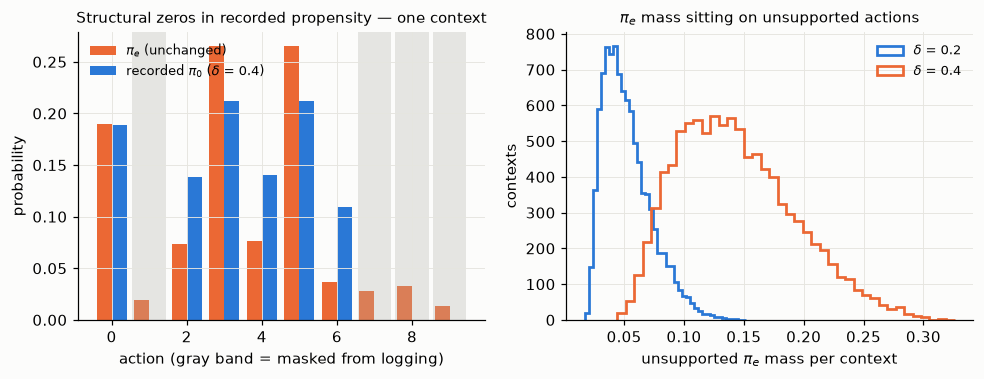

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))

# 왼쪽: 한 컨텍스트에서 π_e vs 기록 π_0 (δ=0.4) — 회색 밴드 = mask 로 제거된 행동
xpos = np.arange(BASE.n_actions)
axes[0].bar(xpos - 0.2, d04.pi_e_dist[i_ctx], width=0.4, color=ACCENT2,
            label="$\\pi_e$ (unchanged)")
axes[0].bar(xpos + 0.2, pi0_rec04[i_ctx], width=0.4, color=ACCENT,
            label="recorded $\\pi_0$ ($\\delta$ = 0.4)")
for a in np.where(~mask04[i_ctx])[0]:
    axes[0].axvspan(a - 0.45, a + 0.45, color=CONTEXT_GRAY, alpha=0.3, lw=0)
axes[0].set_xlabel("action (gray band = masked from logging)")
axes[0].set_ylabel("probability")
axes[0].set_title("Structural zeros in recorded propensity — one context", fontsize=10)
axes[0].legend()

# 오른쪽: 컨텍스트별 미지지 π_e 질량 분포 (δ=0 은 전부 0 이라 생략)
for delta, color in zip((0.2, 0.4), (ACCENT, ACCENT2)):
    axes[1].hist(unsup_by_delta[delta], bins=40, histtype="step", lw=1.8, color=color,
                 label=f"$\\delta$ = {delta:g}")
axes[1].set_xlabel("unsupported $\\pi_e$ mass per context")
axes[1].set_ylabel("contexts")
axes[1].set_title("$\\pi_e$ mass sitting on unsupported actions", fontsize=10)
axes[1].legend()
plt.show()

제거되는 것이 **하위-q** 행동이고 π_e=softmax(3·q) 는 그쪽에 질량을 덜 두므로, 미지지 질량은
작다 — 그러나 0 이 아니고, 그 질량 위의 가치는 **어떤 estimator 도 로그에서 복원할 수 없다**
(식별 불능 — 축 04 의 요지). 더 나쁜 것: 로그만 보는 전역 support proxy 는 이 구조를
**원리적으로 못 본다**(로그 행동의 pscore 는 항상 양수 — 위 재조립 검산). 정본 대조는 LEDGER
`m2-04-proxy-blind`(proxy 전 δ 에서 무반응 vs oracle 미지지 질량 증가)다.

## D. confounding 장치(γ) — 기록 propensity 는 U 를 모른다

축 09 의 노브 `confounding_strength=γ` 는 미관측 U~N(0,1) 을 **로깅 선택**(logits += γ·U·d_a)과
**보상**(+γ·κ·U, κ=`CONF_REWARD_SCALE`)에 동시에 개입시킨다. 이때 두 propensity 가 갈라진다:

- `pscore_logged` — 배포 설정(의도된 정책 softmax(β_log·q))의 확률. **실무에서 기록되는 값.**
- `pscore_true` — U-조건부 실제 정책 π_0(a|x,U) 의 확률. oracle 전용(estimator 비공개).

γ=0 이면 둘은 동일하고, γ>0 이면 같은 (x,a) 에서도 U 에 따라 실제 확률이 요동한다.
γ∈{0, 1.5} 로 그 괴리를 산점과 분위로 본다.

In [9]:
GAMMAS = (0.0, 1.5)
data_by_gamma = {g: make_synthetic_bandit_data(BASE._replace(confounding_strength=g))
                 for g in GAMMAS}

rows = []
for g, d in data_by_gamma.items():
    ratio = d.pscore_true / d.pscore_logged
    rows.append({
        "gamma": g,
        "corr(logged, true)": np.corrcoef(d.pscore_logged, d.pscore_true)[0, 1],
        "ratio_p05": np.quantile(ratio, 0.05),
        "ratio_p50": np.quantile(ratio, 0.50),
        "ratio_p95": np.quantile(ratio, 0.95),
        "share_2x_off": ((ratio > 2.0) | (ratio < 0.5)).mean(),
    })
conf_summary = pd.DataFrame(rows).set_index("gamma")
display(conf_summary.style.format("{:.3f}"))

,"corr(logged, true)",ratio_p05,ratio_p50,ratio_p95,share_2x_off
gamma,,,,,
0.000000,1.000,1.000,1.000,1.000,0.000
1.500000,0.571,0.438,1.722,2.108,0.204


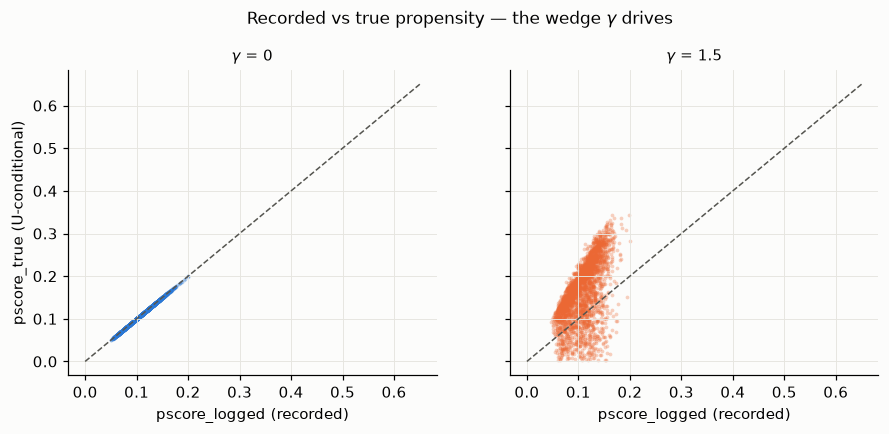

In [10]:
sub = np.random.default_rng(0).choice(BASE.n, size=3000, replace=False)  # 산점 서브샘플(시각화 전용)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharex=True, sharey=True)
lim = (0.0, 0.65)
for ax, (g, color) in zip(axes, ((0.0, ACCENT), (1.5, ACCENT2))):
    d = data_by_gamma[g]
    ax.plot(lim, lim, color=ORACLE_COLOR, lw=1, ls="--")
    ax.scatter(d.pscore_logged[sub], d.pscore_true[sub], s=6, alpha=0.3, color=color, lw=0)
    ax.set_title(f"$\\gamma$ = {g:g}", fontsize=10)
    ax.set_xlabel("pscore_logged (recorded)")
axes[0].set_ylabel("pscore_true (U-conditional)")
fig.suptitle("Recorded vs true propensity — the wedge $\\gamma$ drives", y=1.03, fontsize=11)
plt.show()

In [11]:
# U-주변화 기록판 미리보기(축 18, M8) — γ>0 이면 실제 로깅 분포가 의도 분포에서 벗어난다
for g in GAMMAS:
    dg = data_by_gamma[g]
    marg = marginal_logging_dist(BASE._replace(confounding_strength=g), dg.context[:2000],
                                 n_nodes=200)
    intended = softmax_policy(dg.q_true[:2000], BASE.beta_log)
    print(f"γ={g:g}: max|marginal − intended| = {np.abs(marg - intended).max():.4f}  "
          f"(컨텍스트 2,000개, n_nodes=200)")

γ=0: max|marginal − intended| = 0.0000  (컨텍스트 2,000개, n_nodes=200)
γ=1.5: max|marginal − intended| = 0.0173  (컨텍스트 2,000개, n_nodes=200)


γ=0 에서는 점이 대각선 위에 정확히 놓이고, γ=1.5 에서는 같은 기록값에 대해 실제 확률이
위아래로 넓게 흩어진다. estimator 와 진단은 왼쪽 축(기록값)만 보므로, **weight 기하 기반
진단(ESS·max-weight)은 γ 가 커져도 동일 양호로 읽는다 — bias 만 자란다.** 이것이 축 09
"진단이 못 보는 것" 대조표의 장치이고, 정본 수치는 LEDGER `m2-09-blindspot`(logged ESS
평평 vs oracle-pscore ESS 붕괴·IPS bias 증가)다. U-주변화 propensity 는 불편성을 복원하지
못한다는 정의 구분(`dgp.py` 주석)도 여기서 나온다. 축 18 은 이 γ 장치의 U-주변화(calibrated)
기록판을 만들어 — `marginal_logging_dist`(dgp.py, M8, 위 셀의 괴리가 그 원료) — validity
battery 전체가 관측 동등성으로 눈머는 경계를 전시했다(LEDGER `m8-18-boundary`,
필요조건-검사 co-exhibit).

## E. v_true 검산 — "같은 환경, 다른 로그"의 구조

채점 기준 `v_true = E_x[Σ_a π_e(a|x)·q(x,a)]` 는 **struct_seed 파생 대규모 MC**(n_mc=200,000,
로그 seed 와 독립)로 계산된다. 연속형 보상 설계에서 U·ε 항은 평균 0 이고 π_e 의 행동 선택과
독립이므로, 이 값은 γ·σ 와 무관한 참값이다(`dgp.py` 설계 정리). 두 가지를 탐색 지위로 검산한다:

1. **on-policy 미니 시뮬**: π_e 로 직접 행동을 뽑아 보상 평균을 내면(seed 12개 × n=20,000)
   γ=0 에서도 γ=1.5 에서도 v_true 근방으로 돌아오는가.
2. **seed/struct_seed 분리**: struct_seed 가 같으면 로그 seed 가 달라도 v_true 는 동일하고
   (같은 환경, 다른 로그), struct_seed 가 다르면 환경 자체가 바뀌는가.

정본 sanity 는 probe M0-A(LEDGER `m0a-dgp-sanity`)이고, estimator 구현의 교차검증은 obp
이중 트랙(LEDGER `m1-crossval`)이다 — 여기 수치는 작은 n 의 재현 시연일 뿐이다.

In [12]:
from ope.dgp import _make_structure, _q_true  # noqa: E402 — 해부 전용(정본 사용법 아님)


def onpolicy_value_mc(config: DGPConfig, n: int, seed: int) -> float:
    """π_e 로 직접 굴린 on-policy 보상 평균 — v_true 의 독립 검산용 미니 시뮬."""
    theta, b, _ = _make_structure(config)
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n, config.dim_context))
    q_mc = _q_true(x, theta, b)
    pi_e = softmax_policy(q_mc, config.beta_eval)
    a = (pi_e.cumsum(axis=1) > rng.random((n, 1))).argmax(axis=1)
    u = rng.normal(size=n)
    eps = rng.normal(size=n)
    r = (q_mc[np.arange(n), a]
         + CONF_REWARD_SCALE * config.confounding_strength * u
         + config.reward_noise * eps)
    return float(r.mean())


v_ref = true_policy_value(BASE)
# true_policy_value 는 γ 를 아예 사용하지 않는다 — 설계상 γ-불변임을 그대로 확인
assert v_ref == true_policy_value(BASE._replace(confounding_strength=1.5))
assert v_ref == base.v_true
print(f"v_true (struct-seed MC, n_mc=200k) = {v_ref:.6f}   — γ 를 바꿔도 정의상 동일")

N_SEEDS, N_MC = 12, 20_000
onpol = {g: np.array([onpolicy_value_mc(BASE._replace(confounding_strength=g), N_MC, s)
                      for s in range(N_SEEDS)])
         for g in GAMMAS}
for g, vals in onpol.items():
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    print(f"gamma={g:>3}: on-policy mean = {vals.mean():.6f} ± {2 * se:.6f} (mean ± 2SE, "
          f"{N_SEEDS} seeds × n={N_MC:,})")

v_true (struct-seed MC, n_mc=200k) = 0.715392   — γ 를 바꿔도 정의상 동일


gamma=0.0: on-policy mean = 0.714779 ± 0.001755 (mean ± 2SE, 12 seeds × n=20,000)
gamma=1.5: on-policy mean = 0.715126 ± 0.003324 (mean ± 2SE, 12 seeds × n=20,000)


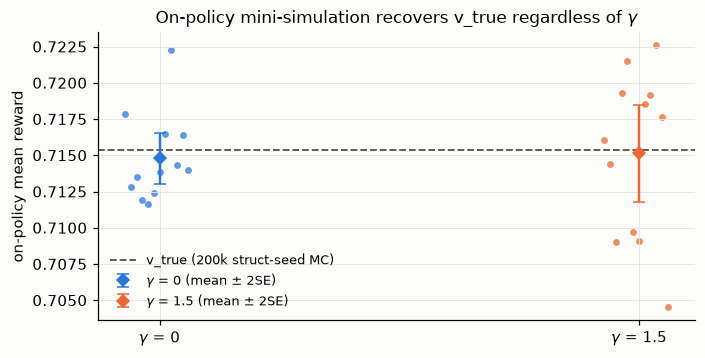

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.axhline(v_ref, color=ORACLE_COLOR, ls="--", lw=1.2, label="v_true (200k struct-seed MC)")
for gi, (g, color) in enumerate(((0.0, ACCENT), (1.5, ACCENT2))):
    vals = onpol[g]
    jitter = gi + (np.arange(len(vals)) - len(vals) / 2) * 0.012
    ax.scatter(jitter, vals, s=20, alpha=0.75, color=color, lw=0)
    m, se = vals.mean(), vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar([gi], [m], yerr=[2 * se], fmt="D", ms=6, capsize=4, lw=1.6, color=color,
                label=f"$\\gamma$ = {g:g} (mean $\\pm$ 2SE)")
ax.set_xticks([0, 1], ["$\\gamma$ = 0", "$\\gamma$ = 1.5"])
ax.set_ylabel("on-policy mean reward")
ax.set_title("On-policy mini-simulation recovers v_true regardless of $\\gamma$", fontsize=11)
ax.legend()
plt.show()

점(seed 별 평균)이 γ 양쪽에서 같은 기준선 주위로 모인다 — U 항이 보상 분산은 키우지만
(γ=1.5 쪽 산포가 더 넓다) 평균은 움직이지 못한다. 이제 **seed/struct_seed 분리**: 같은
struct_seed 는 같은 (θ, b, d_a) — 즉 같은 환경·같은 v_true — 를 뜻하고, 로그 seed 는 그
환경에서 어떤 로그가 떨어지는지만 바꾼다. 축 실험의 MC 반복(seed 만 스윕)이 이 구조 위에 서 있다.

In [14]:
rows = []
for struct_seed in (7, 8, 9):
    for seed in (1, 2):
        cfg = BASE._replace(n=2_000, struct_seed=struct_seed, seed=seed)
        d = make_synthetic_bandit_data(cfg)
        rows.append({
            "struct_seed": struct_seed, "seed": seed,
            "v_true": d.v_true,
            "first_8_actions": str(d.action[:8].tolist()),
        })
sep = pd.DataFrame(rows).set_index(["struct_seed", "seed"])
display(sep.style.format({"v_true": "{:.6f}"}))

struct_seed 블록 안에서 `v_true` 열은 자릿수까지 동일하고 행동 열만 바뀐다 — "같은 환경,
다른 로그". struct_seed 가 바뀌면 v_true 자체가 바뀐다 — 환경이 다른 것이다.

## F. 정리 — 노브 하나 = 실험 축 하나

| DGPConfig 노브 | 이 권의 섹션 | 만드는 기하 | 정본 실험 축 | LEDGER 앵커 |
|---|---|---|---|---|
| `beta_log` | A·B | 로깅 집중 → weight 꼬리·ESS 붕괴 | 02 `02_logging_beta` | `m2-gate` |
| `beta_eval` | A·B | 타깃-로깅 온도 괴리 = w 의 분자 | 03 `03_policy_gap` | `m2-gate` |
| `support_deficiency` δ | C | 기록 분포의 구조적 0·미지지 π_e 질량 | 04 `04_deficient_support` | `m2-04-proxy-blind` |
| `confounding_strength` γ | D | `pscore_logged` ≠ `pscore_true` 쐐기 | 09 `09_confounding_blindspot` | `m2-09-blindspot` |
| `seed` / `struct_seed` | E | 같은 환경, 다른 로그 (MC 반복 구조) | 01–10 공통 규약 | `m0a-dgp-sanity` |

M8 이후 같은 노브들은 **본편 축**의 원료이기도 하다 — 오염 family 는 축 17(validity battery
매트릭스, `m8-17-matrix`), γ 장치는 축 18(관측 동등성 경계, `m8-18-boundary`), β·γ regime 은
축 19(decision-value, `m8-19-decision-value`)로 흘러든다.

이 권의 모든 수치는 탐색 지위다 — 노브별 estimator 성적·게이트 판정의 **정본**은
`experiments/NN_*.py` → `results/tables/NN_*.csv` → [`docs/LEDGER.md`](../docs/LEDGER.md)
경로에만 있다. 권 읽기 순서는 본편 00→03→05 / 백스테이지 01→02→04 다(notebooks/README 재편
예정) — 다음 권(02)은 이 로그를 받아 estimator 7종을 수식→코드→수치로 해부하는 백스테이지다.